Задача поставлена так, что надо по небольшому кропу с текстом понять, перевёрнут текст или нет. То есть это задача бинарной классификации. В целом, понятно, что с этим должна справиться достаточно простая и легковесная модель. Единственная сложность состоит в том, что нужно получить данные для обучения. Я решил для этого самостоятельно сгенерировать синтетический тренировочный набор.

## 1. Генерация данных

Тестовый набор состоит из надписей на русском и английском, кропы разного размера, надписи разных цветов и на разном фоне, бывают надписи специфичной формы (по окружности), многие пережаты, заблюрены и т.д.

Для рендеринга надписей используется `Pillow`. Надписи рендерятся при помощи различных шрифтов с Google Fonts. Надписи генерируются при помощи `wordfreq`. Все надписи рендерятся в нормальной ориентации, потом при обучении и валидации переворачиваются.

Конфиг:

In [2]:
from pathlib import Path
import csv, math, random, re, requests, shutil
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from fontTools.ttLib import TTFont
from wordfreq import top_n_list

# These font families are used only in training
TRAIN_FAMILIES = [
    # common sans-serif
    'roboto', 'opensans', 'notosans', 'ptsans', 'montserrat', 'lato',
    'inter', 'rubik', 'firasans', 'manrope',
    # condensed
    'robotocondensed', 'oswald',
    # serif
    'ptserif', 'notoserif', 'merriweather', 'literata',
    # monospace
    'robotomono', 'ptmono',
    # display / handwritten
    'caveat', 'lobster', 'comfortaa', 'russoone', 'play',
]
# These are held-out font families for fair validation
VAL_FAMILIES = ['jost', 'cuprum', 'lora', 'ibmplexmono', 'neucha', 'yesevaone']
FONTS_DIR = Path('fonts')
OUTPUT_DIR = Path('dataset')
SEED = 42
TRAIN_SAMPLES, VAL_SAMPLES = 50_000, 5_000

Загрузка шрифтов:

In [3]:
# Download only selected TTF files and their licenses.
for family in TRAIN_FAMILIES + VAL_FAMILIES:
    target = FONTS_DIR / family
    target.mkdir(parents=True, exist_ok=True)
    response = requests.get(f'https://api.github.com/repos/google/fonts/contents/ofl/{family}', timeout=30)
    response.raise_for_status()
    for item in response.json():
        if item['name'].lower().endswith('.ttf') or item['name'] == 'OFL.txt':
            path = target / item['name']
            valid = path.exists()
            if valid and path.suffix == '.ttf':
                try: TTFont(path).getBestCmap()
                except Exception: valid = False
            if not valid:
                data = requests.get(item['download_url'], timeout=60)
                data.raise_for_status()
                temporary = path.with_suffix(path.suffix + '.tmp')
                temporary.write_bytes(data.content)
                temporary.replace(path)

# Check that all needed characters are available
alphabet = set(map(ord, 'abcdefghijklmnopqrstuvwxyzабвгдеёжзийклмнопрстуфхцчшщъыьэюя0123456789:/.-_@'))
font_files = list(FONTS_DIR.rglob('*.ttf'))
bad = [p for p in font_files if not alphabet <= set(TTFont(p).getBestCmap() or {})]
assert not bad, f'Fonts without required glyphs: {bad}'
print(f'{len(font_files)} files, {len(TRAIN_FAMILIES) + len(VAL_FAMILIES)} families')

97 files, 29 families


Функции для рендеринга текста:

In [4]:
def load_words(language):
    """Return words that are easy to render for this language (ru/en)"""

    pattern = re.compile('[a-z]+' if language == 'en' else '[а-яё]+')
    return [word for word in top_n_list(language, 30_000)
            if 2 <= len(word) <= 20 and pattern.fullmatch(word)]


def luminance(color):
    """Standard algorithm for calculating luminance from RGB"""

    return sum(channel*weight for channel, weight in zip(color, (.299, .587, .114)))


def random_colors(rng):
    """
    Choose colors for the background and foreground so that
    the text is visible
    """

    background = tuple(rng.randrange(256) for _ in range(3))
    while True:
        foreground = tuple(rng.randrange(256) for _ in range(3))
        if abs(luminance(background) - luminance(foreground)) >= 100:
            return background, foreground

def make_text(words, english_words, rng):
    """
    Generate the text:
    - a single word
    - a short phrase (from 2 to 4 words, semantically unrelated)
    - a number or a date
    - URL
    - identifier/file name
    """

    kind = rng.choices(['word', 'phrase', 'number', 'url', 'identifier'],
                       weights=[45, 25, 10, 12, 8], k=1)[0]
    if kind == 'word':
        text = rng.choice(words)
    elif kind == 'phrase':
        text = ' '.join(rng.choice(words) for _ in range(rng.randint(2, 4)))
    elif kind == 'number':
        date = f'{rng.randint(1,31):02d}.{rng.randint(1,12):02d}.{rng.randint(1990,2035)}'
        text = rng.choice([str(rng.randint(1, 99_999_999)), date])
    elif kind == 'url':
        domain = f'{rng.choice(english_words)}.{rng.choice(["com", "net", "org", "ru"])}'
        text = rng.choice([domain, f'www.{domain}', f'https://{domain}',
                           f'{rng.choice(english_words)}@{domain}'])
    else:
        word = rng.choice(english_words)
        text = rng.choice([f'{word.upper()}-{rng.randint(1,9999)}',
                           f'{word}_{rng.randint(1,999)}', f'{word}.pdf'])

    if kind in ['word', 'phrase'] and rng.random() < .25:
        text = text.upper()
    return text

def load_font(path, size, rng):
    """Load a random font variation"""

    font = ImageFont.truetype(path, size)
    try:
        font.set_variation_by_name(rng.choice(font.get_variation_names()))
    except OSError:
        pass
    return font

def draw_wave(draw, text, font, position, color):
    """Render the text in the shape of wave"""

    x, baseline = position
    for index, character in enumerate(text):
        phase = index / max(1, len(text)-1)
        y = round(.25*font.size*math.sin(2*math.pi*phase))
        draw.text((x, baseline+y), character, font=font, anchor='ls', fill=color)
        x += draw.textlength(character, font=font)

def render_text_layer(text, font, color, style, rng):
    """Render the styled text"""

    margin = 2*font.size
    width = math.ceil(font.getlength(text)) + 2*margin
    layer = Image.new('RGBA', (width, 4*font.size), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)
    position = (margin, 2*font.size)

    if style == 'wave':
        draw_wave(draw, text, font, position, color+(255,))
    else:
        if style == 'shadow':
            offset = max(1, font.size//12)
            draw.text((position[0]+offset, position[1]+offset), text, font=font,
                      anchor='ls', fill=(0, 0, 0, 130))
        stroke = rng.randint(1, max(1, font.size//14)) if style == 'outline' else 0
        outline = tuple(255-channel for channel in color) + (255,)
        draw.text(position, text, font=font, anchor='ls', fill=color+(255,),
                  stroke_width=stroke, stroke_fill=outline)

    return layer.crop(layer.getbbox())

def render(text, font_path, rng):
    """Main function for text rendering"""

    size = min(220, max(12, round(rng.lognormvariate(math.log(48), .65))))
    font = load_font(font_path, size, rng)
    background, foreground = random_colors(rng)
    style = rng.choices(['plain', 'outline', 'shadow', 'wave'],
                        weights=[85, 6, 4, 5], k=1)[0]
    if len(text) <= 3 and style == 'wave':
        style = 'plain'

    layer = render_text_layer(text, font, foreground, style, rng)
    pad_x = round(size*rng.uniform(.03, .20))
    pad_y = round(size*rng.uniform(.02, .10))
    image = Image.new('RGB', (layer.width+2*pad_x, layer.height+2*pad_y), background)
    image.paste(layer, (pad_x, pad_y), layer)
    image.thumbnail((1600, 492), Image.Resampling.LANCZOS)
    return image

def degrade(image, rng):
    """
    Apply degradations to the generated text crop:
    blur, bilinear resizing and JPEG compression
    """

    quality = rng.choices(['clean', 'moderate', 'severe'], weights=[70, 20, 10], k=1)[0]
    if quality == 'clean':
        return image, 95

    if quality == 'moderate':
        scale = rng.uniform(.45, .80)
        blur = rng.uniform(.2, .7)
        jpeg_quality = rng.randint(60, 90)
    else:
        scale = rng.uniform(.15, .40)
        blur = rng.uniform(.5, 1.5)
        jpeg_quality = rng.randint(25, 55)

    original_size = image.size
    small_size = (max(1, round(image.width*scale)), max(1, round(image.height*scale)))
    image = image.resize(small_size, Image.Resampling.BILINEAR)
    image = image.resize(original_size, Image.Resampling.BILINEAR)
    if rng.random() < .60:
        image = image.filter(ImageFilter.GaussianBlur(blur))
    return image, jpeg_quality

def generate(split, count, families, word_pools, seed):
    """Generate the images for specified split along with the metadata csv"""
    
    rng = random.Random(seed)
    fonts = {family: list((FONTS_DIR/family).glob('*.ttf')) for family in families}
    folder = OUTPUT_DIR / split
    folder.mkdir(parents=True, exist_ok=True)

    with (OUTPUT_DIR/f'{split}.csv').open('w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['image', 'text', 'language', 'font'])

        for index in range(count):
            language = rng.choice(['en', 'ru'])
            text = make_text(word_pools[language], word_pools['en'], rng)
            family = rng.choice(families)
            font_path = rng.choice(fonts[family])
            image, jpeg_quality = degrade(render(text, font_path, rng), rng)

            # Save in jpg to apply JPEG compression degradation for free!
            name = f'{split}_{index:05d}.jpg'
            image.save(folder/name, quality=jpeg_quality)
            writer.writerow([f'{split}/{name}', text, language, family])
            if (index + 1) % 1000 == 0:
                print(split, index + 1)

Генерация датасета:

In [5]:
# If dataset exists, regenerate it
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

rng = random.Random(SEED)
train_words = {}
val_words = {}

# Use different words for training and validation
for language in ['en', 'ru']:
    words = load_words(language)
    rng.shuffle(words)
    split = round(len(words) * .9)
    train_words[language] = words[:split]
    val_words[language] = words[split:]

generate('train', TRAIN_SAMPLES, TRAIN_FAMILIES, train_words, SEED)
generate('val', VAL_SAMPLES, VAL_FAMILIES, val_words, SEED + 1)

train 1000
train 2000
train 3000
train 4000
train 5000
train 6000
train 7000
train 8000
train 9000
train 10000
train 11000
train 12000
train 13000
train 14000
train 15000
train 16000
train 17000
train 18000
train 19000
train 20000
train 21000
train 22000
train 23000
train 24000
train 25000
train 26000
train 27000
train 28000
train 29000
train 30000
train 31000
train 32000
train 33000
train 34000
train 35000
train 36000
train 37000
train 38000
train 39000
train 40000
train 41000
train 42000
train 43000
train 44000
train 45000
train 46000
train 47000
train 48000
train 49000
train 50000
val 1000
val 2000
val 3000
val 4000
val 5000


Визуализация:

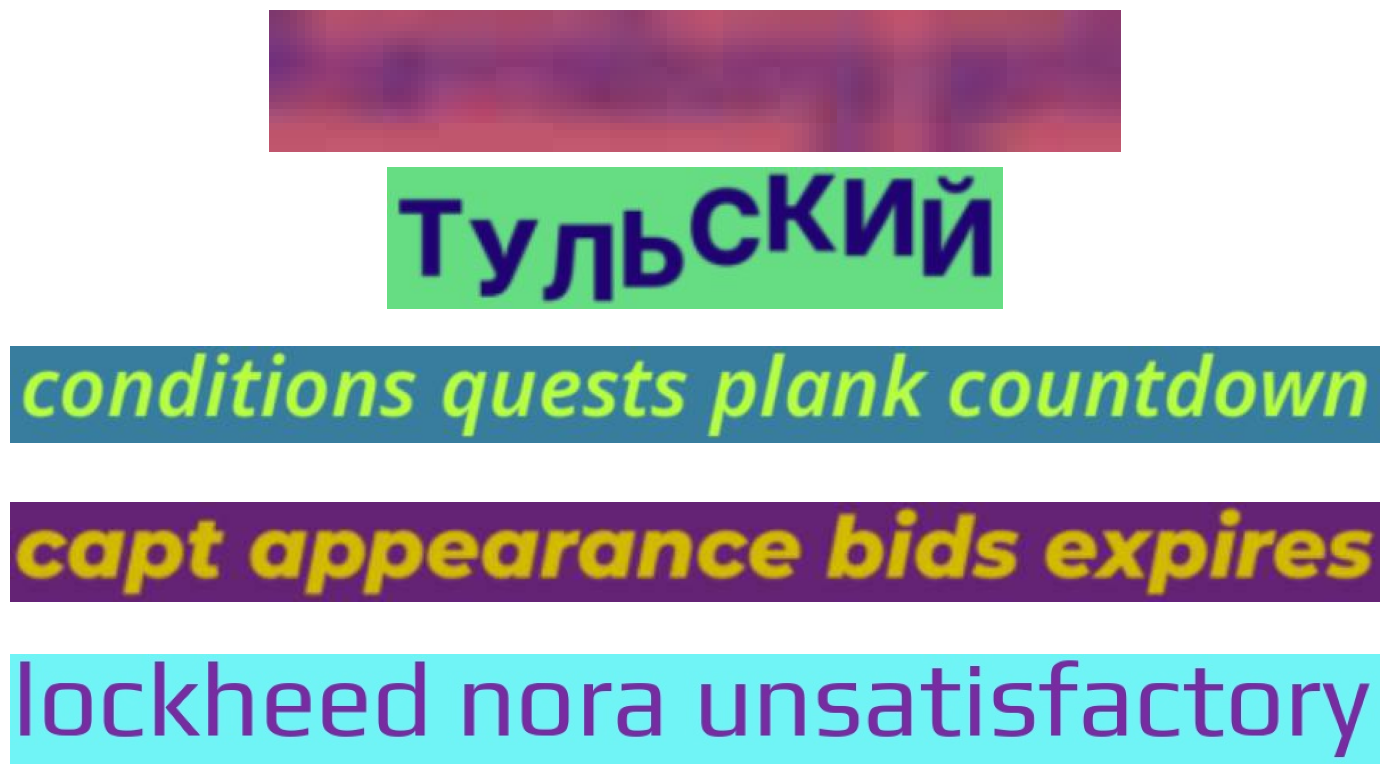

In [8]:
paths = random.sample(list((OUTPUT_DIR/'train').glob('*.jpg')), 5)
fig, axes = plt.subplots(5, 1, figsize=(14, 8))
for axis, path in zip(axes, paths):
    axis.imshow(Image.open(path))
    axis.axis('off')
plt.tight_layout()

## 2. Обучение модели

Для решение задачи используется обучаемая с нуля свёрточная сетка. Я решил, что не имеет смысла брать предобученную, потому что задача довольно простая, а также стандартное предобучение на ImageNet предположительно мало что даст, потому что он содержит в основном объекты, а не текст.

В качестве лосса используется бинарная кросс-энтропия. Отклики определяются в тот же момент, когда надпись либо поворачивается, либо остаётся как есть.

Конфиг:

In [9]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T

# Use rectangular and not square inputs for the text
IMAGE_SIZE = (64, 256)
BATCH_SIZE = 256
NUM_WORKERS = min(8, os.cpu_count() or 1)
# Many epochs for early stopping
EPOCHS = 100
PATIENCE = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.startswith('cuda'): torch.backends.cudnn.benchmark = True
print(DEVICE, torch.cuda.get_device_name(0) if DEVICE.startswith('cuda') else '')

cuda:3 NVIDIA RTX A6000


Функции для аугментаций:

In [10]:
appearance_augment = T.Compose([
    T.ColorJitter(brightness=.25, contrast=.25, saturation=.20, hue=.03),
    T.RandomGrayscale(p=.2),
    T.RandomApply([T.GaussianBlur(3, sigma=(.1, 1.2))], p=.25),
])
to_tensor = T.ToTensor()

def random_rotation(image):
    return image.rotate(random.uniform(-7, 7), Image.Resampling.BICUBIC,
                        fillcolor=image.getpixel((0, 0)))

def resize_and_crop(image, training):
    height, width = IMAGE_SIZE
    new_width = max(1, round(image.width * height / image.height))
    image = image.resize((new_width, height), Image.Resampling.LANCZOS)
    if new_width >= width:
        left = random.randint(0, new_width-width) if training else (new_width-width)//2
        return image.crop((left, 0, left+width, height))
    canvas = Image.new('RGB', (width, height), image.getpixel((0, 0)))
    canvas.paste(image, ((width-new_width)//2, 0))
    return canvas

def prepare(image, training):
    image = resize_and_crop(image, training)
    if training:
        image = random_rotation(image)
        image = appearance_augment(image)
    return to_tensor(image)

Класс для датасета и даталоадеры:

In [11]:
def read_paths(csv_path):
    with csv_path.open(encoding='utf-8') as file:
        return [OUTPUT_DIR/row[0] for row in list(csv.reader(file))[1:]]

class RotationDataset(Dataset):
    def __init__(self, paths, training):
        self.paths = paths
        self.training = training

    # Calculate validation always on both variants
    def __len__(self):
        return len(self.paths) if self.training else 2*len(self.paths)

    def __getitem__(self, index):
        if self.training:
            path, label = self.paths[index], random.randint(0, 1)
        else:
            path, label = self.paths[index//2], index % 2
        image = Image.open(path).convert('RGB')
        if label: image = image.transpose(Image.Transpose.ROTATE_180)
        return prepare(image, self.training), torch.tensor(label, dtype=torch.float32)

train_paths = read_paths(OUTPUT_DIR/'train.csv')
val_paths = read_paths(OUTPUT_DIR/'val.csv')
train_data = RotationDataset(train_paths, training=True)
val_data = RotationDataset(val_paths, training=False)
loader_options = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                      pin_memory=(DEVICE.startswith('cuda')))
if NUM_WORKERS:
    loader_options.update(persistent_workers=True, prefetch_factor=4)
train_loader = DataLoader(train_data, shuffle=True, **loader_options)
val_loader = DataLoader(val_data, shuffle=False, **loader_options)
print(len(train_data), len(val_data))

50000 10000


Визуализация аугментаций:

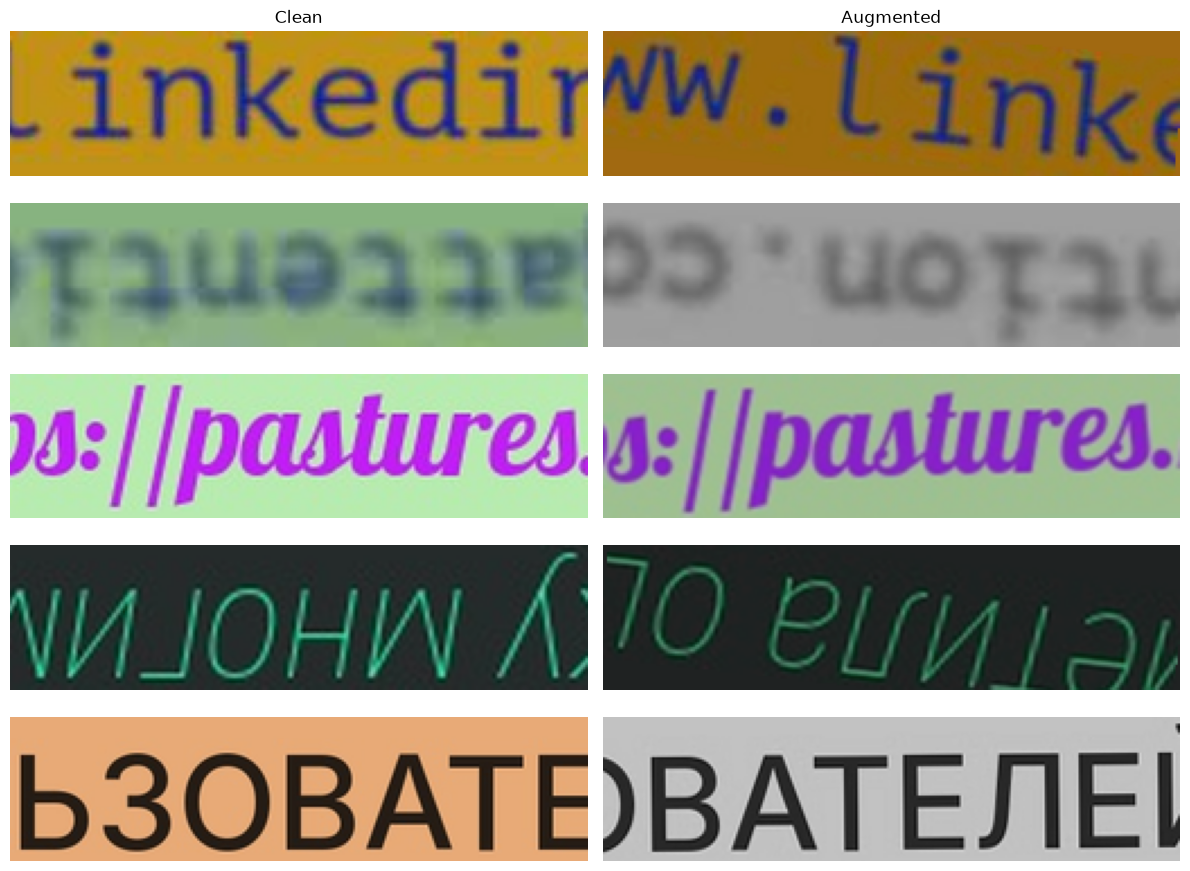

In [14]:
def show(tensor):
    return tensor.permute(1, 2, 0).clamp(0, 1)

fig, axes = plt.subplots(5, 2, figsize=(12, 9))
for row, path in enumerate(random.sample(train_paths, 5)):
    image = Image.open(path).convert('RGB')
    label = row % 2
    if label: image = image.transpose(Image.Transpose.ROTATE_180)
    axes[row, 0].imshow(show(prepare(image, False)))
    axes[row, 1].imshow(show(prepare(image, True)))
    axes[row, 0].set_ylabel(f'label={label}')
for axis in axes.flat: axis.axis('off')
axes[0, 0].set_title('Clean')
axes[0, 1].set_title('Augmented')
plt.tight_layout()

Сама модель:
Используется всего 4 свёрточных слоя, поэтому обучение идёт и без skip-connections.

In [15]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: (batch_size, 3, 64, 256)
        self.features = nn.Sequential(
            # (batch_size, 24, 32, 128)
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            nn.SiLU(),
            nn.MaxPool2d(2),

            # (batch_size, 48, 16, 64)
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.SiLU(),
            nn.MaxPool2d(2),

            # (batch_size, 96, 8, 32)
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.SiLU(),
            nn.MaxPool2d(2),

            # (batch_size, 128, 4, 16)
            nn.Conv2d(96, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 2 * 4, 128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        # Apply both mean and max pooling along the width
        x = torch.cat([x.mean(dim=3), x.amax(dim=3)], dim=1)
        return self.classifier(x.flatten(1)).squeeze(1)

model = TinyCNN().to(DEVICE)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters')

295,297 parameters


Основной цикл обучения:

In [16]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5)
train_losses, val_losses = [], []
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = torch.zeros((), device=DEVICE)
    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach() * len(images)
    train_losses.append((total_loss / len(train_data)).item())

    model.eval()
    total_loss = torch.zeros((), device=DEVICE)
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            total_loss += criterion(model(images), labels).detach() * len(images)
    val_losses.append((total_loss / len(val_data)).item())
    # Save the model when validation loss is low
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), 'best_model.pt')
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(f'{epoch+1:02d}: train={train_losses[-1]:.4f} val={val_losses[-1]:.4f} lr={scheduler.get_last_lr()[0]:.2e}')
    scheduler.step()
    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping after {epoch+1} epochs')
        break

01: train=0.7093 val=0.6943 lr=3.00e-03
02: train=0.6942 val=0.6939 lr=3.00e-03
03: train=0.6941 val=0.6927 lr=3.00e-03
04: train=0.6935 val=0.6928 lr=2.99e-03
05: train=0.6936 val=0.6930 lr=2.99e-03
06: train=0.6930 val=0.6929 lr=2.98e-03
07: train=0.6925 val=0.6925 lr=2.97e-03
08: train=0.6512 val=0.4772 lr=2.96e-03
09: train=0.3710 val=0.2741 lr=2.95e-03
10: train=0.2144 val=0.1971 lr=2.94e-03
11: train=0.1697 val=0.1529 lr=2.93e-03
12: train=0.1435 val=0.1807 lr=2.91e-03
13: train=0.1294 val=0.1278 lr=2.90e-03
14: train=0.1189 val=0.1162 lr=2.88e-03
15: train=0.1060 val=0.1184 lr=2.86e-03
16: train=0.1008 val=0.1188 lr=2.84e-03
17: train=0.0954 val=0.1093 lr=2.82e-03
18: train=0.0904 val=0.1416 lr=2.79e-03
19: train=0.0840 val=0.1192 lr=2.77e-03
20: train=0.0820 val=0.1041 lr=2.74e-03
21: train=0.0838 val=0.0894 lr=2.71e-03
22: train=0.0747 val=0.0894 lr=2.69e-03
23: train=0.0735 val=0.0804 lr=2.66e-03
24: train=0.0749 val=0.1222 lr=2.63e-03
25: train=0.0724 val=0.0886 lr=2.59e-03


График лосса:

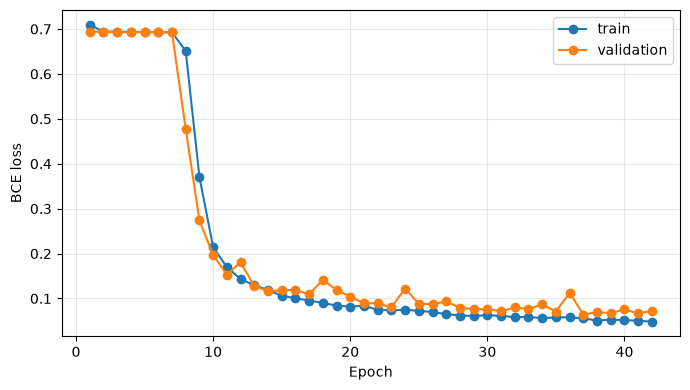

In [17]:
plt.figure(figsize=(7, 4))
epochs = range(1, len(train_losses)+1)
plt.plot(epochs, train_losses, marker='o', label='train')
plt.plot(epochs, val_losses, marker='o', label='validation')
plt.xlabel('Epoch')
plt.ylabel('BCE loss')
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()

## 3. Тестирование модели

Загружаем лучший чекпойнт и тестовые изображения. Используется та же предобработка, что и на валидации: resize, центральный crop или padding.

In [ ]:
# test/test_<idx>.png
TEST_DIR = Path('test')
CHECKPOINT_PATH = Path('best_model.pt')
SUBMISSION_PATH = Path('submission.csv')
test_paths = sorted(TEST_DIR.glob('*.png'))

class TestDataset(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = Image.open(path).convert('RGB')
        return prepare(image, training=False), path.stem

test_loader = DataLoader(TestDataset(test_paths), shuffle=False, **loader_options)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'{len(test_paths)} test images')

20000 test images


Для каждого изображения считаем вероятности два раза: в текущей ориентации и в повёрнутой. Это нужно, чтобы вероятности складывались в единицу.

In [19]:
image_ids, probabilities = [], []
with torch.inference_mode():
    for images, batch_ids in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        rotated = torch.rot90(images, 2, dims=(-2, -1))
        logits = (model(images) - model(rotated)) / 2
        image_ids.extend(batch_ids)
        probabilities.extend(torch.sigmoid(logits).cpu().tolist())

with SUBMISSION_PATH.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['image_id', 'p_180'])
    writer.writerows((image_id, f'{probability:.8f}')
                     for image_id, probability in zip(image_ids, probabilities))

print(f'Saved {len(probabilities)} predictions to {SUBMISSION_PATH}')

Saved 20000 predictions to submission.csv


Визуализация случайных тестовых надписей с выходами модели:

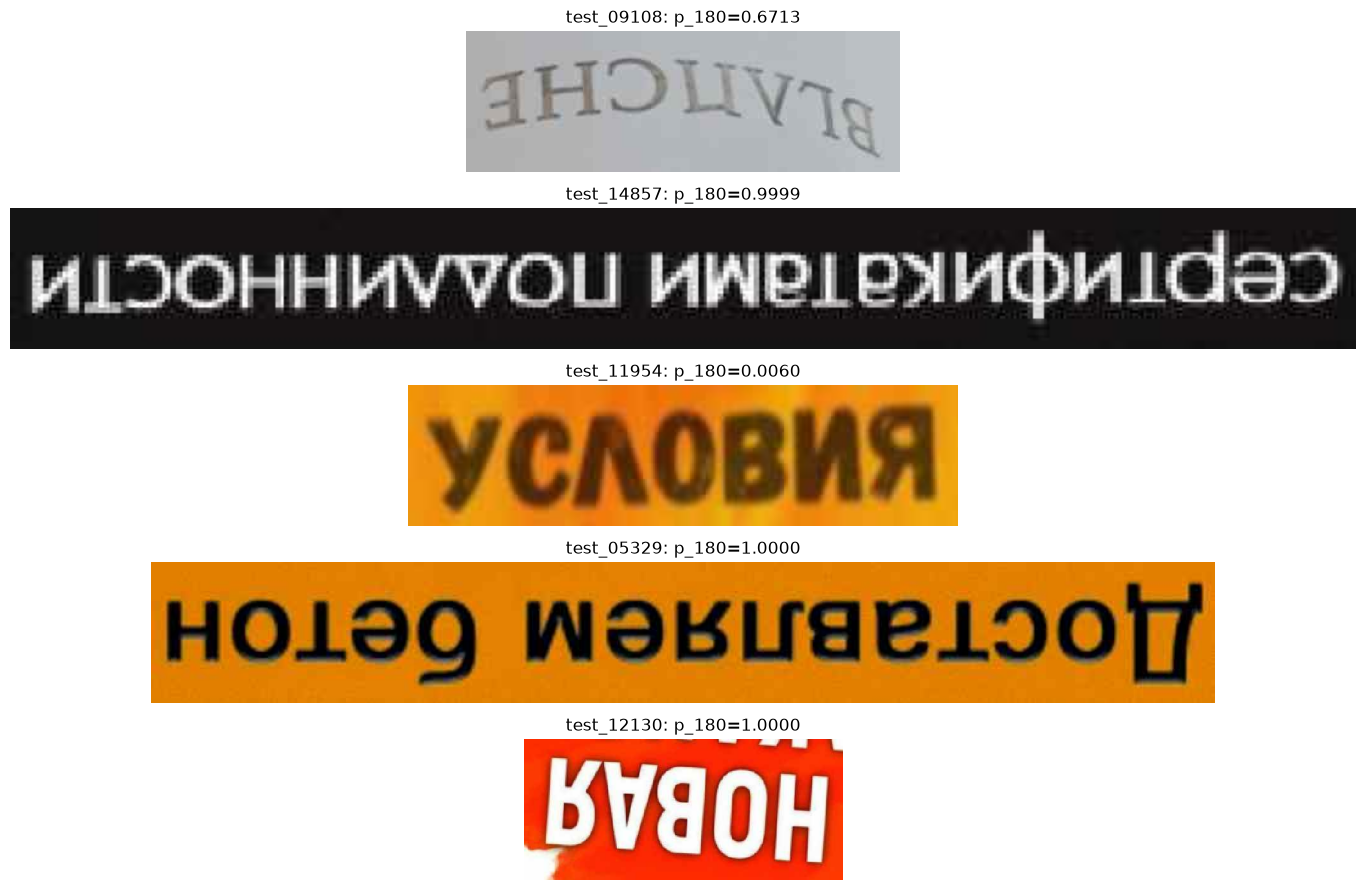

In [23]:
prediction_by_id = dict(zip(image_ids, probabilities))
examples = random.sample(test_paths, 5)
fig, axes = plt.subplots(5, 1, figsize=(14, 9))

for axis, path in zip(axes, examples):
    probability = prediction_by_id[path.stem]
    axis.imshow(Image.open(path))
    axis.set_title(f'{path.stem}: p_180={probability:.4f}')
    axis.axis('off')

plt.tight_layout()